In [1]:
import pandas as pd

# Read the files
df_original = pd.read_csv("toyDetector_10000.csv")
df_ordered = pd.read_csv("toyDetector_10000_ordered.csv")
df_shuffled = pd.read_csv("toyDetector_10000_shuffled.csv")

# Check if they have the same data (ignoring row order)
is_ordered_equal = df_original.equals(df_ordered)
is_shuffled_equal = df_original.equals(df_shuffled)

print("Original == Ordered (same order)?", is_ordered_equal)
print("Original == Shuffled (same order)?", is_shuffled_equal)

# Check if they contain the same rows (regardless of order)
same_as_ordered = df_original.sort_values(by=df_original.columns.tolist()).reset_index(drop=True).equals(
    df_ordered.sort_values(by=df_ordered.columns.tolist()).reset_index(drop=True)
)

same_as_shuffled = df_original.sort_values(by=df_original.columns.tolist()).reset_index(drop=True).equals(
    df_shuffled.sort_values(by=df_shuffled.columns.tolist()).reset_index(drop=True)
)

print("Original vs Ordered (same content, any order)?", same_as_ordered)
print("Original vs Shuffled (same content, any order)?", same_as_shuffled)


Original == Ordered (same order)? False
Original == Shuffled (same order)? False
Original vs Ordered (same content, any order)? False
Original vs Shuffled (same content, any order)? False


In [3]:
df_normal = pd.read_csv("toyDetector_10000.csv")
df_ordered = pd.read_csv("toyDetector_10000_ordered.csv")

# Step 1: Compare the shape
column_names = ['x', 'y', 'rho', 'delta']

# Read the CSVs with no header
df_normal = pd.read_csv("toyDetector_10000.csv", header=None, names=column_names)
df_ordered = pd.read_csv("toyDetector_10000_ordered.csv", header=None, names=column_names)

# Columns to match row-by-row
columns_to_match = ['x', 'y']

# Match each row in ordered to a row in normal
matches = []
unmatched = []

for i, row in df_ordered[columns_to_match].iterrows():
    match = df_normal[columns_to_match].eq(row).all(axis=1)
    match_idx = match[match].index
    if not match_idx.empty:
        matches.append((i, match_idx[0]))
    else:
        unmatched.append(i)

# Results
print(f"✅ Matched {len(matches)} out of {len(df_ordered)} rows.")
if unmatched:
    print(f"❌ Unmatched rows in ordered (first 10): {unmatched[:10]}")


✅ Matched 10000 out of 10000 rows.


In [4]:
perm = [df_normal[columns_to_match].eq(row).all(axis=1).idxmax()
        for _, row in df_ordered[columns_to_match].iterrows()]
perm = pd.Series(perm)

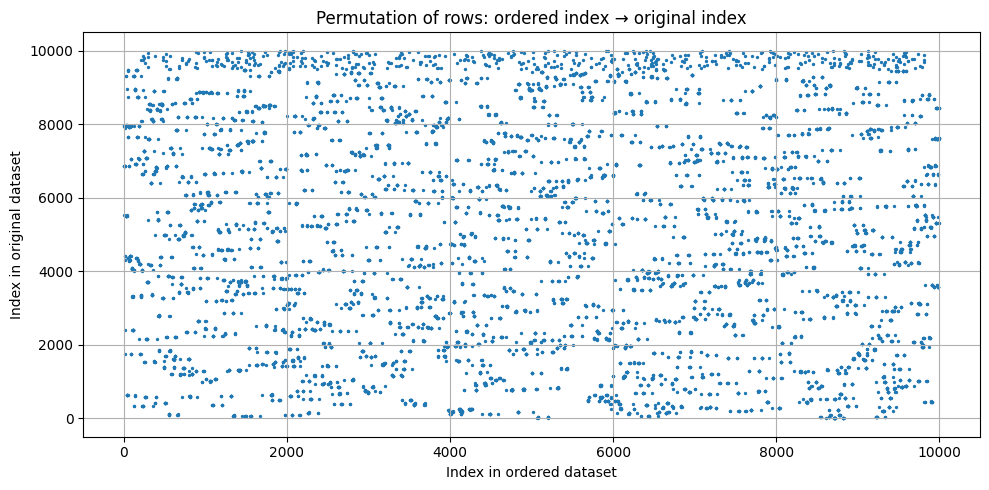

In [7]:
import matplotlib.pyplot as plt

# Compute permutation: index in df_normal for each row in df_ordered
perm = [df_normal[columns_to_match].eq(row).all(axis=1).idxmax()
        for _, row in df_ordered[columns_to_match].iterrows()]
perm = pd.Series(perm)

# Scatterplot
plt.figure(figsize=(10, 5))
plt.scatter(range(len(perm)), perm, s=2)
plt.title("Permutation of rows: ordered index → original index")
plt.xlabel("Index in ordered dataset")
plt.ylabel("Index in original dataset")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
column_names = ['x', 'y', 'rho', 'delta']
df_ordered = pd.read_csv("toyDetector_10000_ordered.csv", header=None, names=column_names)

# Initialize layer logic
layerdiffs = []
layermin = df_ordered.loc[0, 'y']
layermax = df_ordered.loc[0, 'y']

for i in range(1, len(df_ordered)):
    x_curr = df_ordered.loc[i, 'x']
    x_prev = df_ordered.loc[i - 1, 'x']
    y_curr = df_ordered.loc[i, 'y']

    if x_curr >= x_prev:
        # still in the same layer
        layermin = min(layermin, y_curr)
        layermax = max(layermax, y_curr)
    else:
        # x dropped → new layer detected
        layerdiffs.append(layermax - layermin)
        layermin = y_curr
        layermax = y_curr

# Handle last layer
layerdiffs.append(layermax - layermin)

# Show first 50 layer ranges
print("Layer height ranges (y_max - y_min) per layer:")
print(layerdiffs[:50])

Layer height ranges (y_max - y_min) per layer:
[2.019999999999982, 4.210000000000008, 3.460000000000008, 0.0, 2.3499999999999943, 1.5200000000000102, 0.1699999999999875, 2.640000000000015, 4.030000000000001, 0.0, 0.0, 0.0, 1.549999999999983, 1.3400000000000034, 0.0, 1.200000000000017, 0.6700000000000159, 0.0, 2.680000000000007, 3.7399999999999807, 0.0, 3.0200000000000102, 2.219999999999999, 2.3700000000000045, 3.210000000000008, 2.8000000000000114, 0.5200000000000102, 3.240000000000009, 0.9300000000000068, 4.519999999999982, 0.37000000000000455, 0.2600000000000193, 1.039999999999992, 1.710000000000008, 0.0, 3.240000000000009, 3.130000000000024, 1.0, 1.75, 0.0, 3.1699999999999875, 2.6200000000000045, 0.0, 4.090000000000003, 3.8499999999999943, 1.299999999999983, 3.8799999999999955, 2.6200000000000045, 0.8700000000000045, 0.960000000000008]
